# 📘 Classifying Stack Overflow Posts using LSTM and GRU Models

This notebook compares the performance of — **LSTM (Long Short-Term Memory)**, with and without attention.

We will use the IMDB movie reviews (sentiment analysis) to train the model. Because the average length of this dataset is much higher than the stack overflow dataset.

---

## 🔄 Data Processing Pipeline

The full pipeline for handling and modeling the data is as follows:

1. **Dataset Loading**
   - Load Stack Overflow posts dataset (CSV format).
   - Each sample includes a title and its corresponding category label.

2. **Text Preprocessing**
   - Clean and normalize text (e.g., lowercasing, removing punctuation).
   - Tokenize text into words.
   - Remove out-of-vocabulary (OOV) tokens if necessary.

3. **Embedding with GloVe**
   - Use pre-trained **GloVe word embeddings (100d)** via `gensim.downloader`.
   - Convert each tokenized title into a sequence of vectors.

4. **Sequence Padding**
   - Pad sequences to a fixed length to ensure uniform input shape.

5. **Train/Test Split**
   - Split the dataset into training and testing sets while preserving class distribution.

6. **Model Definition**
   - Implement two **LSTM** based neural models: one without attention and one with attention.
   - Each model ends with a fully connected layer for classification.

7. **Training**
   - Train both models on the training set using cross-entropy loss and an optimizer (e.g., Adam).
   - Monitor performance on the validation/test set during training.

8. **Evaluation**
   - Compute metrics such as accuracy, precision, recall, and F1-score.
   - Compare the results across models and categories.

-----------------------------------------------------------------------

##🔧 Installing Required Dependency
Before proceeding with the rest of the notebook, we need to install the gensim library, which is used for loading and working with pre-trained word embeddings such as Word2Vec or GloVe.

⚠️ Note: Run this cell only once, then restart the runtime (from the Runtime menu in Colab) before continuing with the rest of the notebook. This ensures all dependencies are properly loaded into memory.

In [ ]:
# Run it only one time, then restart the session and go one with the reminding cells
!pip install gensim
# !pip install -U datasets huggingface_hub

##📚 Library Imports & Setup
This cell loads all necessary libraries for data processing, modeling, and evaluation:

PyTorch: Model building and training

Pandas / NumPy: Data handling

Matplotlib / Seaborn: Visualization

Scikit-learn: Data splitting and evaluation

NLTK: Text preprocessing (stopwords, tokenization, lemmatization)

Gensim: Pre-trained word embeddings

In [ ]:
import pandas as pd
import warnings as wrn
wrn.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
import kagglehub
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# from sklearn.metrics import roc_curve, auc
# from sklearn.preprocessing import label_binarize
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from datasets import load_dataset

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

##🔤 Loading GloVe Word Embeddings
This cell loads pre-trained GloVe embeddings using gensim.

We use the "glove-wiki-gigaword-100" model, which provides 100-dimensional vectors for a large vocabulary of English words.

embedding_dim is set to 100, matching the dimensionality of the GloVe vectors.

In [ ]:
# Load GloVe from gensim
glove_model = api.load("glove-wiki-gigaword-100")
embedding_dim = glove_model.vector_size  # 100
PADDING_TOKEN = '</pad>'

In [ ]:
def get_embeddings(tokens):  # get vectors for tokens.

    embeddings = []
    for token in tokens:
        token = token.lower()
        if token in glove_model:
            embeddings.append(glove_model[token])
        else:
            embeddings.append(np.zeros(embedding_dim))

    embeddings = torch.Tensor(embeddings)
    return embeddings


def pad_tokens(tokens, max_len):
    return tokens + [PADDING_TOKEN] * (max_len - len(tokens))


def pad_sequence_embedding(embeddings, max_len):

    padded_embeddings = torch.zeros((max_len - len(embeddings), embedding_dim))
    return torch.cat((embeddings, padded_embeddings), dim=0)

In [ ]:
test_examples = [
    "I am a sentence with seven words",
    "Hello friends"
]

test_examples_tokenized = [word_tokenize(example) for example in test_examples]
test_examples_padded = [pad_tokens(example, max_len=7) for example in test_examples_tokenized]

for example in test_examples:
    print(example)
print('--'*20)
for example in test_examples_tokenized:
    print(example)
print('--'*20)
for example in test_examples_padded:
    print(example)

I am a sentence with seven words
Hello friends
----------------------------------------
['I', 'am', 'a', 'sentence', 'with', 'seven', 'words']
['Hello', 'friends']
----------------------------------------
['I', 'am', 'a', 'sentence', 'with', 'seven', 'words']
['Hello', 'friends', '</pad>', '</pad>', '</pad>', '</pad>', '</pad>']


In [ ]:
non_padded_embeddings = [get_embeddings(example) for example in test_examples_tokenized]
for embedding in non_padded_embeddings:
    print(embedding.shape)

torch.Size([7, 100])
torch.Size([2, 100])


In [ ]:
padded_embeddings = [pad_sequence_embedding(embedding, max_len=7) for embedding in non_padded_embeddings]
for embedding in padded_embeddings:
    print(embedding.shape)

torch.Size([7, 100])
torch.Size([7, 100])


##📥 Loading the Dataset
This cell downloads and loads the StackOverflow Text Classification dataset:

Uses kagglehub to fetch the dataset from Kaggle.

Reads the CSV file containing labeled StackOverflow posts.

Displays the first few rows using df.head() to inspect the data.

In [ ]:
imdb = load_dataset("stanfordnlp/imdb")
train_raw = imdb["train"]
test_raw  = imdb["test"]

In [ ]:
train_df = pd.DataFrame(train_raw).rename(columns={"text": "Title", "label": "Label"})
# train_df['split'] = 'train'
test_df = pd.DataFrame(test_raw).rename(columns={"text": "Title", "label": "Label"})
# test_df['split'] = 'test'

df = pd.concat([train_df, test_df])
df['Label'] = df['Label'].apply(lambda x: 'positive' if x == 1 else 'negative)
df.head()

,Title,Label,split
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,train
1,"""I Am Curious: Yellow"" is a risible and preten...",0,train
2,If only to avoid making this type of film in t...,0,train
3,This film was probably inspired by Godard's Ma...,0,train
4,"Oh, brother...after hearing about this ridicul...",0,train


##📊 Dataset Overview & Class Balance
This cell gives a high-level overview of the dataset:

Displays column names and data types

Shows how many samples belong to each category

Visualizes the category distribution using a bar chart

This helps detect class imbalance, which can affect model performance if not addressed.

📄 Dataset Summary:

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   50000 non-null  object
 1   Label   50000 non-null  int64 
 2   split   50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.5+ MB

🧠 Number of Samples per Category:

Label
0    25000
1    25000
Name: count, dtype: int64



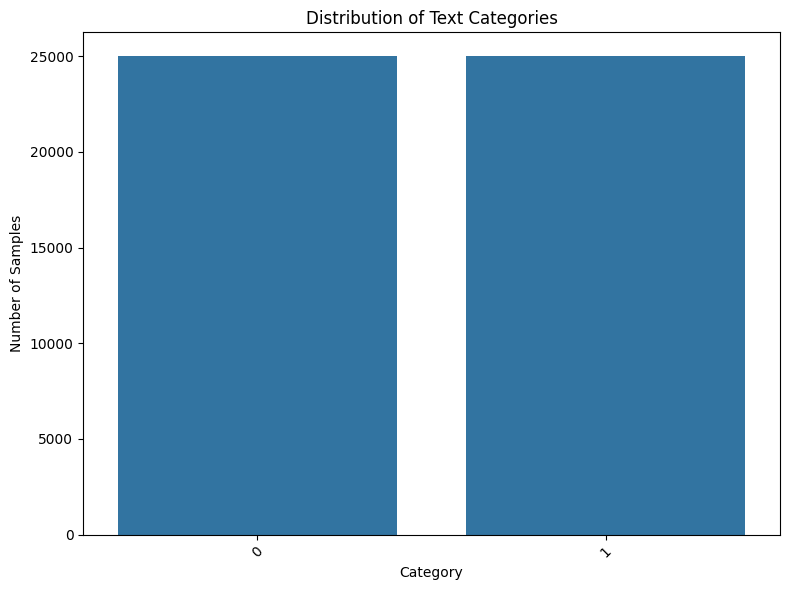

In [ ]:
# Display basic structure of the dataset
print("📄 Dataset Summary:\n")
df.info()

# Show how many samples exist for each category
print("\n🧠 Number of Samples per Category:\n")
print(df['Label'].value_counts())
print("=======================================\n")
# Plot distribution of categories
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Label', order=df['Label'].value_counts().index)
plt.title('Distribution of Text Categories')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##✍️ Title Length Analysis (Word Count)
In this cell, we analyze the number of words in each text title. This is crucial because NLP models like RNNs and LSTMs operate on sequences of tokens (words), not characters.


 * Calculate the average, minimum, and maximum word count.
 * Visualize the distribution using a histogram.
 * This helps us choose an appropriate sequence length during preprocessing.

📝 Average Word Count: 231.16
🔢 Max Word Count: 2470
🔢 Min Word Count: 4


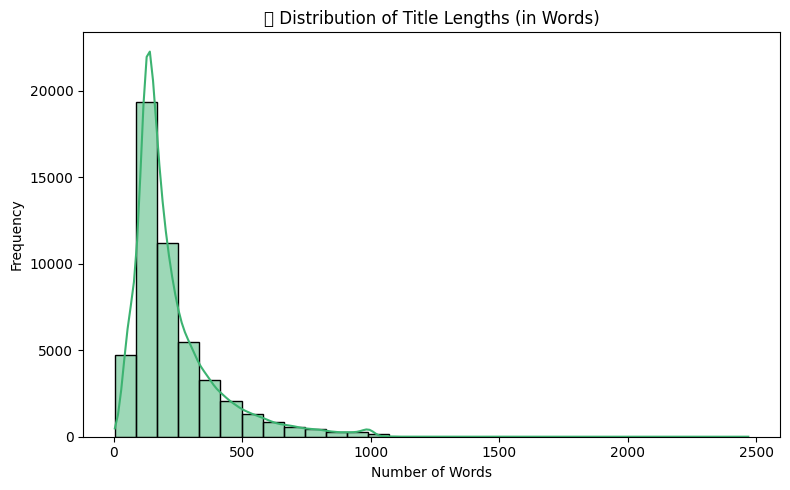

In [ ]:
# Compute word count for each title
word_counts = df['Title'].apply(lambda x: len(x.split()))

# Summary statistics
print(f"📝 Average Word Count: {word_counts.mean():.2f}")
print(f"🔢 Max Word Count: {word_counts.max()}")
print(f"🔢 Min Word Count: {word_counts.min()}")

# Plot word count distribution
plt.figure(figsize=(8, 5))
sns.histplot(word_counts, bins=30, kde=True, color='mediumseagreen')
plt.title('📊 Distribution of Title Lengths (in Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


##🔍 Example Titles by Category
To better understand the nature of the text in each category, this cell prints a sample title from each label in the dataset.

This helps us:

 * Inspect the kind of questions or issues discussed

 * Spot common patterns in phrasing or keywords

 * Prepare for later steps in preprocessing and modeling



In [ ]:
# ✅ Define the list of unique labels
unique_labels = df['Label'].unique()

for label in unique_labels:
    print(f"📚 Samples from '{label}':")
    samples = df[df['Label'] == label]['Title'].head(3)
    for i, sample in enumerate(samples, 1):
        print(f"  {i}. {sample}")
    print("-" * 60)

📚 Samples from '0':
  1. I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are

##📦 Text Preprocessing Class
This class provides a way to clean and tokenize text data. It performs the following steps:

Lowercases the text
* Removes punctuation and numbers
* Tokenizes the text into words
* Removes common stopwords
* Lemmatizes each word (e.g., “running” → “run”)

In [ ]:
class TextPreprocessor:
    """
    A simple text cleaner that lowercases, removes punctuation,
    tokenizes, removes stopwords, and lemmatizes.
    """
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def preprocess(self, text):
        text = re.sub(r'[^a-zA-Z1-9\s]', '', text)  # Remove punctuation
        text = text.lower()                      # Lowercase
        tokens = word_tokenize(text)             # Tokenize
        tokens = [t for t in tokens if t not in self.stop_words]  # Remove stopwords
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]   # Lemmatize
        return tokens

preprocessor = TextPreprocessor()

In [ ]:
# Apply preprocessing using the .preprocess() method
df['Clean_Title'] = df['Title'].apply(preprocessor.preprocess)

In [ ]:
df.head()

,Title,Label,split,Clean_Title
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,train,"[rented, curiousyellow, video, store, controve..."
1,"""I Am Curious: Yellow"" is a risible and preten...",0,train,"[curious, yellow, risible, pretentious, steami..."
2,If only to avoid making this type of film in t...,0,train,"[avoid, making, type, film, future, film, inte..."
3,This film was probably inspired by Godard's Ma...,0,train,"[film, probably, inspired, godard, masculin, f..."
4,"Oh, brother...after hearing about this ridicul...",0,train,"[oh, brotherafter, hearing, ridiculous, film, ..."


#Word Embedding with GloVe
In this step, we convert each cleaned title into a sequence of word embeddings using the pre-trained GloVe model:

##🔍 How It Works:
For each token in a cleaned title:

 * If the token exists in GloVe, we use its vector.
 * If not, we use a zero vector (to handle unknown words).
 * Each title is now represented as a tensor of shape (sequence length × embedding dimension).

##🧠 Why This Matters:
This transforms the raw text into a numerical format that can be fed into deep learning models like RNNs or LSTMs.

In [ ]:
get_embeddings(['I', 'Like', 'Machine', 'Learning']).shape

torch.Size([4, 100])

In [ ]:
df['Vectorized_Title'] = df['Clean_Title'].apply(lambda x: get_embeddings(x))

In [ ]:
df.head()

,Title,Label,split,Clean_Title,Vectorized_Title
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,train,"[rented, curiousyellow, video, store, controve...","[[tensor(0.2676), tensor(-0.4152), tensor(-0.4..."
1,"""I Am Curious: Yellow"" is a risible and preten...",0,train,"[curious, yellow, risible, pretentious, steami...","[[tensor(0.2376), tensor(0.2079), tensor(0.387..."
2,If only to avoid making this type of film in t...,0,train,"[avoid, making, type, film, future, film, inte...","[[tensor(-0.4967), tensor(-0.4734), tensor(0.2..."
3,This film was probably inspired by Godard's Ma...,0,train,"[film, probably, inspired, godard, masculin, f...","[[tensor(0.1992), tensor(-0.0497), tensor(0.24..."
4,"Oh, brother...after hearing about this ridicul...",0,train,"[oh, brotherafter, hearing, ridiculous, film, ...","[[tensor(-0.6666), tensor(0.4327), tensor(1.31..."


In [ ]:
for vector in df['Vectorized_Title'][:5]:
    print(vector.shape)

torch.Size([152, 100])
torch.Size([119, 100])
torch.Size([52, 100])
torch.Size([61, 100])
torch.Size([172, 100])


##🧼 Removing Empty Vectorized Samples
Some titles may be completely made up of unknown or removed tokens (e.g., stopwords or rare words), which results in empty tensors during vectorization.

This step filters out those cases by keeping only rows where Vectorized_Title is non-empty.

In [ ]:
# Filter out all rows that have empty tensors
df = df[df["Vectorized_Title"].apply(lambda x: len(x) > 0)]
df.value_counts('Label')

,count
Label,
0,25000
1,25000


##🧪 Splitting the Dataset (Train / Validation / Test)
To evaluate our model properly, we split the dataset into three parts:

* Train Set (60%) — used to train the model

* Validation Set (20%) — used to tune model hyperparameters

* Test Set (20%) — used to evaluate final model performance

##📌 Notes:
* Splits are stratified by label, meaning the class distribution is preserved across all sets.

* This helps ensure that each subset is representative of the original dataset.

In [ ]:
# Split the dataset into train and test sets with an 80/20 split, stratified by the 'Label' column
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

# Split the train dataset into train and validation sets with an 80/20 split, stratified by the 'Label' column
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42, stratify=train_df['Label'])

##📊 Visualizing Label Distribution in Train/Val/Test Splits

This plot helps verify that the class distribution is preserved across all three dataset splits:

* Ensures fairness in training and evaluation
* Confirms that stratified splitting worked as expected
* Useful for spotting imbalances early on

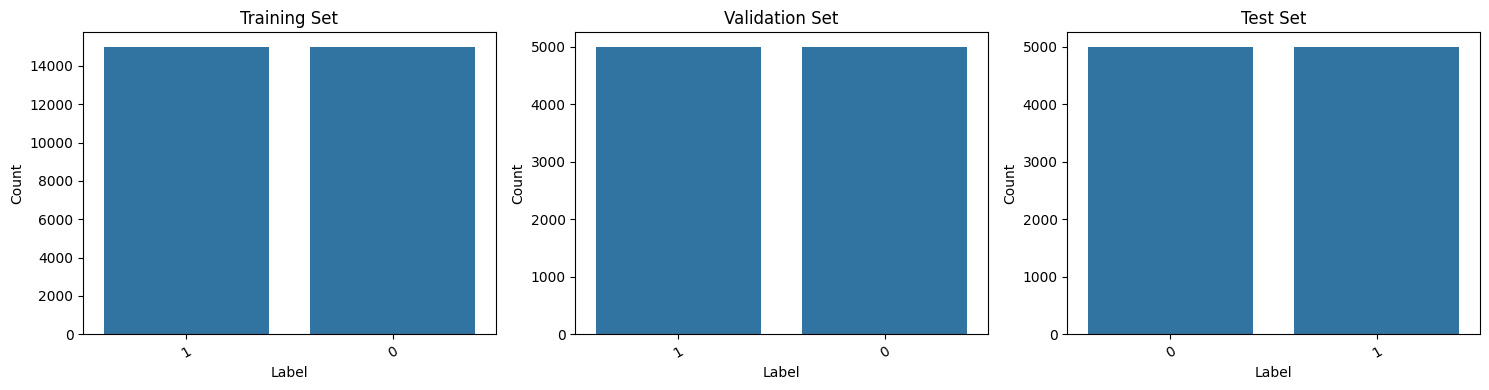

In [ ]:
# Plot label distributions for train, val, and test sets
def plot_label_distributions(datasets, titles):
    plt.figure(figsize=(15, 4))
    for i, (df, title) in enumerate(zip(datasets, titles), 1):
        plt.subplot(1, 3, i)
        sns.countplot(x='Label', data=df, order=df['Label'].value_counts().index)
        plt.title(title)
        plt.xlabel('Label')
        plt.ylabel('Count')
        plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Call the function
plot_label_distributions(
    [train_df, val_df, test_df],
    ['Training Set', 'Validation Set', 'Test Set']
)


##📦 Custom PyTorch Dataset & Collate Function
This cell defines two key components for handling our vectorized text data in PyTorch:

##🗂️ StackOverflowDataset
A custom Dataset class that:

* Loads each sample from the DataFrame
* Converts the vectorized title to a tensor
* Maps the text label to a numeric index

##🧱 collate_batch
A custom collate function used by the DataLoader to:

* Pad each sequence in a batch to the same length
* Stack them into a single tensor for training

✅ This is important for feeding variable-length sequences into RNN-based models in mini-batches.

##📥 Preparing DataLoaders for Model Training
This cell handles the final preparation of the data before training:

##🗂️ Label Encoding
A dictionary label_to_idx maps each category name ("spark", "ml", "security") to a unique index.

##📦 Dataset Initialization
Creates instances of StackOverflowDataset for the train, validation, and test splits.

##🚚 DataLoader Setup

* Wraps each dataset in a DataLoader with:
* A defined batch_size (64)
* Shuffling for the training set only
* A custom collate_fn to pad sequences within each batch

In [ ]:
# label_to_idx = {"spark": 0, "ml": 1, "security": 2}
label_to_idx = {"Negative": 0, "Positive": 1}


class StackOverflowDataset(Dataset):
    """
    Custom PyTorch Dataset for StackOverflow vectorized titles.
    """
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = torch.stack(list(self.df.iloc[idx]["Vectorized_Title"]))
        label = torch.tensor(label_to_idx[self.df.iloc[idx]["Label"]], dtype=torch.long)
        return text, label


def collate_batch(batch):
    """
    Pads sequences in a batch to the same length.
    """
    vectors, labels = zip(*batch)
    max_len = max(len(vec) for vec in vectors)

    padded_vectors = [pad_sequence_embedding(vec, max_len) for vec in vectors]
    return torch.stack(padded_vectors), torch.tensor(labels, dtype=torch.long)

In [ ]:
# Initialize the StackOverflowDataset objects for training, validation, and testing
train_dataset = StackOverflowDataset(train_df)
val_dataset = StackOverflowDataset(val_df)
test_dataset = StackOverflowDataset(test_df)

# Set the batch size for data loading
batch_size = 64

# Initialize DataLoaders for training, validation, and testing
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

In [ ]:
test_out = train_dataloader.__iter__().__next__()[0]

# which one is batch size?
# which one is sequence length? (number of words)
# which one is embedding dim?

# 64 is dim 0
# 13 is dim 1
# 100 is dim 2

print(test_out.shape)

torch.Size([64, 461, 100])


#🧠 RNN-Based Classifiers
This cell defines two custom LSTM based PyTorch models for text classification, one that has attention and one that doesn't.


> both models take a sequence of word embeddings as input and output logits for class prediction.





In [ ]:
class LSTMClassifier(nn.Module):
    """
    A custom LSTM-based classifier for text classification.
    """
    def __init__(self, embed_dim, hidden_dim, num_classes, dropout=0.5):
        """
        Initializes a new LSTMClassifier object.

        Args:
        embed_dim (int): the dimension of the word embeddings
        hidden_dim (int): the size of the hidden state in the LSTM layer
        num_classes (int): the number of classes in the classification task
        dropout (float, optional): the dropout probability (default: 0.5)
        """
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        """
        Defines the forward pass for the LSTMClassifier.

        Args:
        text (torch.Tensor): the input text tensor

        Returns:
        torch.Tensor: the logits for the classification task
        """
        lstm_out, _ = self.lstm(text)
        pooled = self.dropout(torch.mean(lstm_out, dim=1))
        logits = self.fc(pooled)
        return logits


class LSTMAttentionClassifier(nn.Module):
    """
    A custom LSTM-based classifier for text classification.
    """
    def __init__(self, embed_dim, hidden_dim, num_classes, dropout=0.5):
        """
        Initializes a new LSTMClassifier object.

        Args:
        embed_dim (int): the dimension of the word embeddings
        hidden_dim (int): the size of the hidden state in the LSTM layer
        num_classes (int): the number of classes in the classification task
        dropout (float, optional): the dropout probability (default: 0.5)
        """
        super(LSTMAttentionClassifier, self).__init__()
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=2,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Defines the forward pass for the LSTMClassifier.

        Args:
        text (torch.Tensor): the input text tensor

        Returns:
        torch.Tensor: the logits for the classification task
        """
        mask = (x != 0).all(dim=-1)
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out)
        query = lstm_out[:, -1:, :]
        context, attn_w = self.attn(
            query, lstm_out, lstm_out,             # Q, K, V
            key_padding_mask=~mask           # True where we should ignore
        )
        context = context.squeeze(1)         # (B, H)
        logits    = self.fc(context)
        alpha   = attn_w.squeeze(1)          # (B, T)

        return logits


##🧪 Training with Accuracy Tracking
This function trains the model and now logs both:

* Loss and accuracy on the training set
* Loss and accuracy on the validation set
* This helps monitor learning progress and overfitting during training.

In [ ]:
def train_and_evaluate(model, num_epochs=10):
    """
    Trains a model, tracks loss and accuracy on train/val sets,
    and returns test predictions.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'using device {device}')
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        train_loss, correct_train, total_train = 0, 0, 0
        for texts, labels in train_dataloader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(texts)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        # --- Validation ---
        model.eval()
        val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_dataloader:
                texts, labels = texts.to(device), labels.to(device)
                logits = model(texts)
                loss = criterion(logits, labels)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        # --- Logging ---
        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = val_loss / len(val_dataloader)
        train_acc = correct_train / total_train
        val_acc = correct_val / total_val
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- Testing ---
    model.eval()
    true_labels, pred_labels = [], []
    with torch.no_grad():
        for texts, labels in test_dataloader:
            texts, labels = texts.to(device), labels.to(device)
            logits = model(texts)
            predictions = torch.argmax(logits, dim=1)
            true_labels.extend(labels.tolist())
            pred_labels.extend(predictions.tolist())

    return true_labels, pred_labels


In [ ]:
# Model configuration
embed_dim = 100       # From GloVe vectors
hidden_dim = 128      # Hidden size for RNN layers
num_classes = 3       # Number of output categories

# LSTM Model
lstm_model = LSTMClassifier(embed_dim, hidden_dim, num_classes)
print("📘 Training and evaluating LSTM model:")
lstm_true_labels, lstm_pred_labels = train_and_evaluate(lstm_model)

lstm_a_model = LSTMAttentionClassifier(embed_dim, hidden_dim, num_classes)
print("📘 Training and evaluating LSTM Attention model:")
lstm_a_true_labels, lstm_a_pred_labels = train_and_evaluate(lstm_a_model)

📘 Training and evaluating LSTM Attention model:
using device cuda
Epoch 1/10 | Train Loss: 0.4746 | Train Acc: 0.7654 | Val Loss: 0.3752 | Val Acc: 0.8323
Epoch 2/10 | Train Loss: 0.3566 | Train Acc: 0.8477 | Val Loss: 0.3340 | Val Acc: 0.8528
Epoch 3/10 | Train Loss: 0.3264 | Train Acc: 0.8620 | Val Loss: 0.3079 | Val Acc: 0.8687
Epoch 4/10 | Train Loss: 0.3033 | Train Acc: 0.8739 | Val Loss: 0.2934 | Val Acc: 0.8809
Epoch 5/10 | Train Loss: 0.2833 | Train Acc: 0.8827 | Val Loss: 0.2864 | Val Acc: 0.8799
Epoch 6/10 | Train Loss: 0.2690 | Train Acc: 0.8890 | Val Loss: 0.2941 | Val Acc: 0.8778
Epoch 7/10 | Train Loss: 0.2472 | Train Acc: 0.8991 | Val Loss: 0.2880 | Val Acc: 0.8844
Epoch 8/10 | Train Loss: 0.2271 | Train Acc: 0.9060 | Val Loss: 0.2886 | Val Acc: 0.8824
Epoch 9/10 | Train Loss: 0.1993 | Train Acc: 0.9198 | Val Loss: 0.2846 | Val Acc: 0.8833
Epoch 10/10 | Train Loss: 0.1782 | Train Acc: 0.9286 | Val Loss: 0.3000 | Val Acc: 0.8845


##🧾 Classification Reports
This cell prints the performance metrics of each model using classification_report from sklearn.

In [ ]:
print("LSTM Model Performance:")
print(classification_report(lstm_true_labels, lstm_pred_labels, target_names=list(map(str, label_to_idx.keys())), digits=4))

print("LSTM Attention Model Performance:")
print(classification_report(lstm_a_true_labels, lstm_a_pred_labels, target_names=list(map(str, label_to_idx.keys())), digits=4))

LSTM Model Performance:
              precision    recall  f1-score   support

           0     0.8097    0.9156    0.8594      5000
           1     0.9029    0.7848    0.8397      5000

    accuracy                         0.8502     10000
   macro avg     0.8563    0.8502    0.8496     10000
weighted avg     0.8563    0.8502    0.8496     10000

LSTM Attention Model Performance:
              precision    recall  f1-score   support

           0     0.8846    0.8704    0.8774      5000
           1     0.8724    0.8864    0.8794      5000

    accuracy                         0.8784     10000
   macro avg     0.8785    0.8784    0.8784     10000
weighted avg     0.8785    0.8784    0.8784     10000



##🔍 Confusion Matrices: LSTM vs GRU vs RNN
This visualization shows how each model performs on the test set in terms of true vs. predicted labels:

* Helps identify where each model struggles (e.g., confusing one class with another)

* Useful for error analysis and model comparison

In [ ]:
def plot_confusion_matrices(true_labels, lstm_preds, attention_preds):
    """
    Plots confusion matrices for LSTM, GRU, and RNN classifiers.
    """
    preds = [lstm_preds, attention_preds]
    titles = ['Without Attention', 'With Attention']
    labels = list(label_to_idx.keys())

    fig, axes = plt.subplots(1, len(preds), figsize=(18, 5))
    for ax, pred, title in zip(axes, preds, titles):
        cm = confusion_matrix(true_labels, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_title(f"{title} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()


In [ ]:
plot_confusion_matrices(lstm_true_labels, lstm_pred_labels, gru_pred_labels, rnn_pred_labels)

## Contirbuted by: Yazan Alshoibi
adapted from: [RNNs to classify Stack Overflow posts using PyTorch -
jashdubal](https://github.com/jashdubal/stackoverflow-classifier)

##🧠 Exercises
To deepen your understanding and improve model performance, try implementing the following:

##🔧 1. Hyperparameter Tuning
Experiment with different:

* Learning rates (e.g., 0.001, 0.0005, 0.0001)

* Optimizers (Adam, AdamW, SGD)

* Batch sizes (16, 32, 64)

* Number of epochs

* Plot training/validation loss and accuracy for each run to find the optimal combination.

##🧼 2. Try Different Preprocessing Techniques
Test the impact of:

* Lowercasing all text

* Removing stopwords

* Stemming vs. Lemmatization

* Removing rare words or frequent tokens (e.g., punctuation, digits)

* Re-evaluate model performance after each preprocessing change.

##🏗️ 3. Add More Layers
Add depth to your model:

* Use stacked RNN/LSTM/GRU layers (e.g., num_layers=2 or 3)

* Apply dropout between layers to prevent overfitting

* Compare the results with your single-layer architecture.